# Laboratorio 5 – Análisis de tráfico

## 1. Instalación e importación de librerías

In [1]:
!pip install scapy pandas numpy matplotlib scikit-learn

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- --------------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scapy.all import rdpcap, IP, TCP, UDP, Raw
from sklearn.ensemble import IsolationForest

plt.rcParams['figure.figsize'] = (10, 5)

## 2. Cargar el archivo pcap

In [5]:
pcap_path = 'analisis_paquetes.pcap'
packets = rdpcap(pcap_path)

print('Tipo de dato:', type(packets))
print('Cantidad total de paquetes:', len(packets))

Tipo de dato: <class 'scapy.plist.PacketList'>
Cantidad total de paquetes: 62


## 3. Testeo de la herramienta

Se imprimen 10 paquetes, su longitud y un resumen de su contenido.

In [6]:
for i, pkt in enumerate(packets[:10], start=1):
    print(f'Paquete {i}')
    print('Longitud:', len(pkt))
    print('Resumen:', pkt.summary())
    print('-' * 80)

Paquete 1
Longitud: 975
Resumen: Ether / IP / UDP / DNS Qry b'google.com.' / Raw
--------------------------------------------------------------------------------
Paquete 2
Longitud: 98
Resumen: Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
--------------------------------------------------------------------------------
Paquete 3
Longitud: 989
Resumen: Ether / IP / UDP / DNS Qry b'google.com.' / Raw
--------------------------------------------------------------------------------
Paquete 4
Longitud: 98
Resumen: Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
--------------------------------------------------------------------------------
Paquete 5
Longitud: 1026
Resumen: Ether / IP / UDP / DNS Qry b'google.com.' / Raw
--------------------------------------------------------------------------------
Paquete 6
Longitud: 98
Resumen: Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
--------------------------------------------------------------------------------
Paquete 7
Longitud

## 4. Convertir el pcap a DataFrame

Se extraen las columnas principales: dirección IP origen, dirección IP destino, puerto origen, puerto destino, longitud del payload y longitud total del paquete.

In [7]:
rows = []

for pkt in packets:
    if IP in pkt:
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst
        pkt_len = len(pkt)

        src_port = None
        dst_port = None
        payload_bytes = b''

        if UDP in pkt:
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport
            payload_bytes = bytes(pkt[UDP].payload)
        elif TCP in pkt:
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
            payload_bytes = bytes(pkt[TCP].payload)

        payload_len = len(payload_bytes)

        rows.append({
            'src_ip': src_ip,
            'dst_ip': dst_ip,
            'src_port': src_port,
            'dst_port': dst_port,
            'payload_len': payload_len,
            'pkt_len': pkt_len,
            'payload_bytes': payload_bytes,
        })

df = pd.DataFrame(rows)
df.head(10)

,src_ip,dst_ip,src_port,dst_port,payload_len,pkt_len,payload_bytes
0,10.1.10.53,84.54.22.33,53,53,933,975,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...
1,84.54.22.33,10.1.10.53,53,53,56,98,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...
2,10.1.10.53,84.54.22.33,53,53,947,989,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...
3,84.54.22.33,10.1.10.53,53,53,56,98,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...
4,10.1.10.53,84.54.22.33,53,53,984,1026,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...
5,84.54.22.33,10.1.10.53,53,53,56,98,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...
6,10.1.10.53,84.54.22.33,53,53,970,1012,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...
7,84.54.22.33,10.1.10.53,53,53,56,98,"b""\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00..."
8,10.1.10.53,84.54.22.33,53,53,975,1017,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...
9,84.54.22.33,10.1.10.53,53,53,56,98,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...


## 5. Mostrar columnas solicitadas

Columnas: Src Address, Dst Address, Src Port y Dst Port.

In [8]:
df[['src_ip', 'dst_ip', 'src_port', 'dst_port']].head(20)

,src_ip,dst_ip,src_port,dst_port
0,10.1.10.53,84.54.22.33,53,53
1,84.54.22.33,10.1.10.53,53,53
2,10.1.10.53,84.54.22.33,53,53
3,84.54.22.33,10.1.10.53,53,53
4,10.1.10.53,84.54.22.33,53,53
5,84.54.22.33,10.1.10.53,53,53
6,10.1.10.53,84.54.22.33,53,53
7,84.54.22.33,10.1.10.53,53,53
8,10.1.10.53,84.54.22.33,53,53
9,84.54.22.33,10.1.10.53,53,53


## 6. Estadísticas básicas

In [9]:
# a) IP origen más frecuente
src_counts = df['src_ip'].value_counts()
ip_origen_frecuente = src_counts.idxmax()

print('IP origen más frecuente:', ip_origen_frecuente)
print(src_counts.head(10))

IP origen más frecuente: 10.1.10.53
src_ip
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


In [10]:
# b) IP destino más frecuente
dst_counts = df['dst_ip'].value_counts()
ip_destino_frecuente = dst_counts.idxmax()

print('IP destino más frecuente:', ip_destino_frecuente)
print(dst_counts.head(10))

IP destino más frecuente: 10.1.10.53
dst_ip
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


In [11]:
# c) ¿A qué IPs se comunica la IP del inciso a?
ips_comunicadas = df[df['src_ip'] == ip_origen_frecuente]['dst_ip'].value_counts()
ips_comunicadas

dst_ip
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

In [12]:
# d) ¿A qué puertos destino se comunica la IP del inciso a?
puertos_destino_ip_frec = df[df['src_ip'] == ip_origen_frecuente]['dst_port'].value_counts()
puertos_destino_ip_frec

dst_port
53    31
Name: count, dtype: int64

In [13]:
# e) ¿A qué puertos origen se comunica la IP del inciso b?
puertos_origen_ip_dest = df[df['dst_ip'] == ip_destino_frecuente]['src_port'].value_counts()
puertos_origen_ip_dest

src_port
53    31
Name: count, dtype: int64

### f) Propósito de los puertos más frecuentes

Esta función ayuda a interpretar los puertos más comunes.

In [14]:
def describir_puerto(puerto):
    catalogo = {
        20: 'FTP de datos',
        21: 'FTP de control',
        22: 'SSH',
        23: 'Telnet',
        25: 'SMTP',
        53: 'DNS',
        67: 'DHCP servidor',
        68: 'DHCP cliente',
        69: 'TFTP',
        80: 'HTTP',
        110: 'POP3',
        123: 'NTP',
        143: 'IMAP',
        161: 'SNMP',
        443: 'HTTPS',
        3306: 'MySQL',
        3389: 'RDP',
        5432: 'PostgreSQL',
        8080: 'HTTP alternativo',
    }
    return catalogo.get(int(puerto), 'Puerto no identificado en catálogo básico')

top_d = puertos_destino_ip_frec.head(10)
top_e = puertos_origen_ip_dest.head(10)

print('Puertos destino más frecuentes del inciso d:')
for puerto in top_d.index:
    if pd.notna(puerto):
        print(f'Puerto {int(puerto)}: {describir_puerto(puerto)}')

print('\nPuertos origen más frecuentes del inciso e:')
for puerto in top_e.index:
    if pd.notna(puerto):
        print(f'Puerto {int(puerto)}: {describir_puerto(puerto)}')

Puertos destino más frecuentes del inciso d:
Puerto 53: DNS

Puertos origen más frecuentes del inciso e:
Puerto 53: DNS


## 7. Z-score sobre el tamaño del payload

Se calcula el Z-score usando la media y desviación estándar del mismo pcap.

In [15]:
media_payload = df['payload_len'].mean()
desv_payload = df['payload_len'].std(ddof=0)

df['z_score_payload'] = (df['payload_len'] - media_payload) / desv_payload

anomalias_z2 = df[np.abs(df['z_score_payload']) > 2].copy()
anomalias_z3 = df[np.abs(df['z_score_payload']) > 3].copy()

print('Media payload:', media_payload)
print('Desviación estándar payload:', desv_payload)
print('Cantidad con |Z| > 2:', len(anomalias_z2))
print('Cantidad con |Z| > 3:', len(anomalias_z3))

Media payload: 481.33870967741933
Desviación estándar payload: 456.5430744454914
Cantidad con |Z| > 2: 0
Cantidad con |Z| > 3: 0


In [18]:
media_dns = 50
desv_dns = 15

df["z_score_dns_ref"] = (df["payload_len"] - media_dns) / desv_dns
anomalias_dns = df[np.abs(df["z_score_dns_ref"]) > 3].copy()

print("Cantidad detectada con referencia DNS:", len(anomalias_dns))
anomalias_dns[["src_ip", "dst_ip", "src_port", "dst_port", "payload_len", "pkt_len", "z_score_dns_ref"]].head(50)

Cantidad detectada con referencia DNS: 29


,src_ip,dst_ip,src_port,dst_port,payload_len,pkt_len,z_score_dns_ref
0,10.1.10.53,84.54.22.33,53,53,933,975,58.866667
2,10.1.10.53,84.54.22.33,53,53,947,989,59.800000
4,10.1.10.53,84.54.22.33,53,53,984,1026,62.266667
6,10.1.10.53,84.54.22.33,53,53,970,1012,61.333333
8,10.1.10.53,84.54.22.33,53,53,975,1017,61.666667
10,10.1.10.53,84.54.22.33,53,53,1017,1059,64.466667
12,10.1.10.53,84.54.22.33,53,53,980,1022,62.000000
14,10.1.10.53,84.54.22.33,53,53,951,993,60.066667
16,10.1.10.53,84.54.22.33,53,53,931,973,58.733333
18,10.1.10.53,84.54.22.33,53,53,964,1006,60.933333


### Histograma de `payload_len`

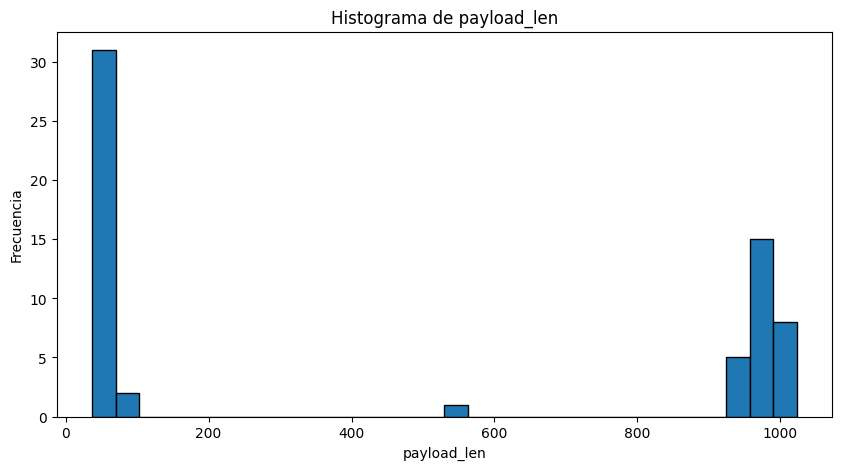

In [19]:
plt.figure()
plt.hist(df['payload_len'], bins=30, edgecolor='black')
plt.title('Histograma de payload_len')
plt.xlabel('payload_len')
plt.ylabel('Frecuencia')
plt.show()

### Inciso 4b
El histograma de payload_len muestra que la distribución de los tamaños de payload no es normal, ya que los datos se concentran en dos grupos separados: uno de valores pequeños (aproximadamente entre 40 y 80 bytes) y otro de valores grandes (alrededor de 900 a 1050 bytes).

Esta distribución no tiene forma de campana, sino que presenta una separación clara entre valores pequeños y grandes. Debido a esto, la media y la desviación estándar calculadas a partir de todos los datos no representan adecuadamente el comportamiento típico del protocolo. Como resultado, el Z-score no detecta anomalías porque los valores grandes influyen en la media y hacen que no se consideren suficientemente extremos.

Esto demuestra que el Z-score puede fallar cuando los datos no siguen una distribución normal, lo cual es común en el tráfico de red.


## 8. Z-score usando conocimiento de dominio

Para DNS se usará media de referencia de 50 bytes y desviación estándar de 15 bytes.

In [20]:
media_dns = 50
desv_dns = 15

df['z_score_dns_ref'] = (df['payload_len'] - media_dns) / desv_dns
anomalias_dns = df[np.abs(df['z_score_dns_ref']) > 3].copy()

print('Cantidad detectada con referencia DNS:', len(anomalias_dns))
anomalias_dns[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'payload_len', 'pkt_len', 'z_score_dns_ref']].head(100)

Cantidad detectada con referencia DNS: 29


,src_ip,dst_ip,src_port,dst_port,payload_len,pkt_len,z_score_dns_ref
0,10.1.10.53,84.54.22.33,53,53,933,975,58.866667
2,10.1.10.53,84.54.22.33,53,53,947,989,59.800000
4,10.1.10.53,84.54.22.33,53,53,984,1026,62.266667
6,10.1.10.53,84.54.22.33,53,53,970,1012,61.333333
8,10.1.10.53,84.54.22.33,53,53,975,1017,61.666667
10,10.1.10.53,84.54.22.33,53,53,1017,1059,64.466667
12,10.1.10.53,84.54.22.33,53,53,980,1022,62.000000
14,10.1.10.53,84.54.22.33,53,53,951,993,60.066667
16,10.1.10.53,84.54.22.33,53,53,931,973,58.733333
18,10.1.10.53,84.54.22.33,53,53,964,1006,60.933333


### Respuesta breve del inciso 4d

Este resultado demuestra que el conocimiento del protocolo es importante al detectar anomalías. Cuando se usó la media del propio pcap, no se detectaron valores anómalos porque la distribución no era normal. Sin embargo, al usar valores típicos de DNS (≈50 bytes), se identificaron varios payloads demasiado grandes (≈900–1000 bytes), lo cual no es común en consultas DNS. Esto muestra que conocer el comportamiento normal del protocolo mejora la detección de tráfico sospechoso.

## 9. Gráficas de payload

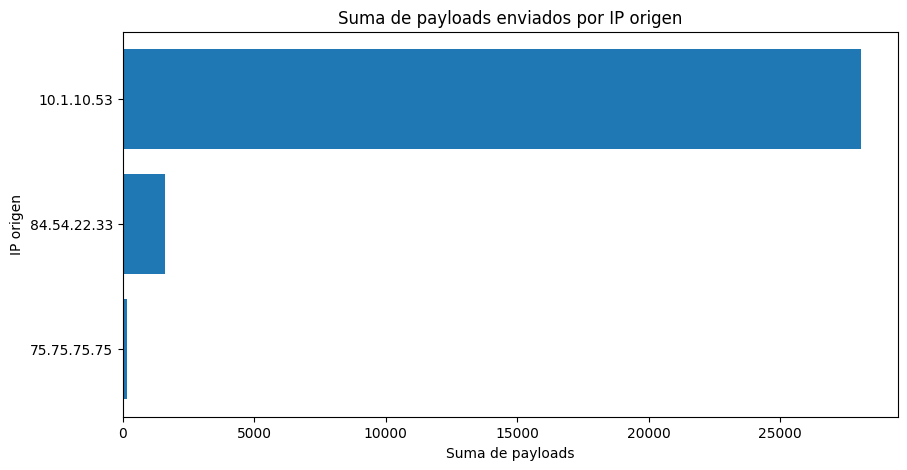

In [21]:
# a) Suma de payloads enviados por IP origen
payload_por_src_ip = df.groupby('src_ip')['payload_len'].sum().sort_values()

plt.figure()
plt.barh(payload_por_src_ip.index.astype(str), payload_por_src_ip.values)
plt.title('Suma de payloads enviados por IP origen')
plt.xlabel('Suma de payloads')
plt.ylabel('IP origen')
plt.show()

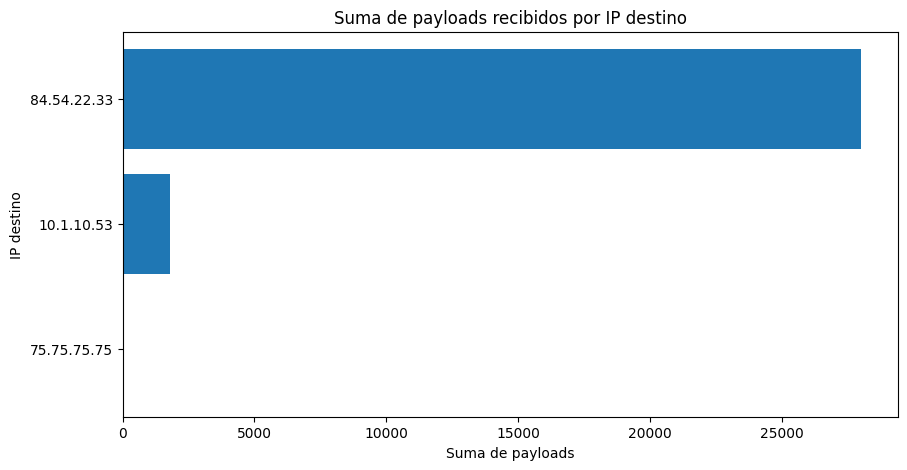

In [22]:
# b) Suma de payloads recibidos por IP destino
payload_por_dst_ip = df.groupby('dst_ip')['payload_len'].sum().sort_values()

plt.figure()
plt.barh(payload_por_dst_ip.index.astype(str), payload_por_dst_ip.values)
plt.title('Suma de payloads recibidos por IP destino')
plt.xlabel('Suma de payloads')
plt.ylabel('IP destino')
plt.show()

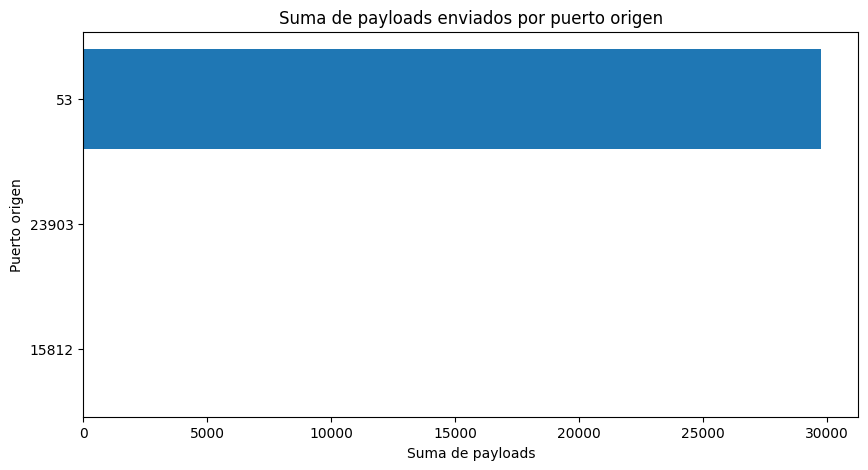

In [23]:
# c) Suma de payloads enviados por puerto origen
payload_por_src_port = df.groupby('src_port')['payload_len'].sum().sort_values()

plt.figure()
plt.barh(payload_por_src_port.index.astype(str), payload_por_src_port.values)
plt.title('Suma de payloads enviados por puerto origen')
plt.xlabel('Suma de payloads')
plt.ylabel('Puerto origen')
plt.show()

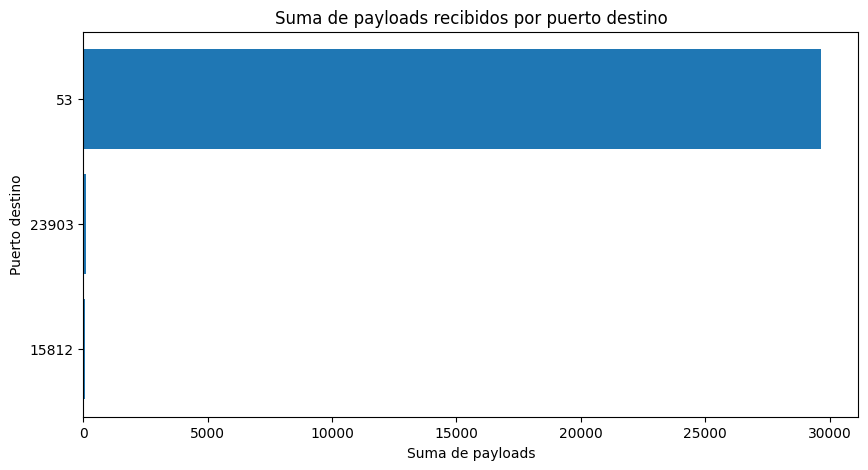

In [24]:
# d) Suma de payloads recibidos por puerto destino
payload_por_dst_port = df.groupby('dst_port')['payload_len'].sum().sort_values()

plt.figure()
plt.barh(payload_por_dst_port.index.astype(str), payload_por_dst_port.values)
plt.title('Suma de payloads recibidos por puerto destino')
plt.xlabel('Suma de payloads')
plt.ylabel('Puerto destino')
plt.show()

## 10. Detección automática con Isolation Forest

In [25]:
X = df[['payload_len', 'pkt_len']].copy()

contamination = len(anomalias_dns) / len(df)
contamination = min(max(contamination, 0.001), 0.5)

modelo_if = IsolationForest(contamination=contamination, random_state=42)
df['if_pred'] = modelo_if.fit_predict(X)

anomalias_if = df[df['if_pred'] == -1].copy()

print('Contamination usada:', contamination)
print('Cantidad de anomalías detectadas:', len(anomalias_if))
anomalias_if[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'payload_len', 'pkt_len']].head(100)

Contamination usada: 0.46774193548387094
Cantidad de anomalías detectadas: 29


,src_ip,dst_ip,src_port,dst_port,payload_len,pkt_len
0,10.1.10.53,84.54.22.33,53,53,933,975
2,10.1.10.53,84.54.22.33,53,53,947,989
4,10.1.10.53,84.54.22.33,53,53,984,1026
6,10.1.10.53,84.54.22.33,53,53,970,1012
8,10.1.10.53,84.54.22.33,53,53,975,1017
10,10.1.10.53,84.54.22.33,53,53,1017,1059
12,10.1.10.53,84.54.22.33,53,53,980,1022
14,10.1.10.53,84.54.22.33,53,53,951,993
16,10.1.10.53,84.54.22.33,53,53,931,973
18,10.1.10.53,84.54.22.33,53,53,964,1006


### Respuesta breve del inciso 6b

Las anomalías detectadas con Isolation Forest coinciden con las identificadas con el Z-score, ya que se observan los mismos paquetes con tamaños de payload muy grandes enviados entre las IPs 10.1.10.53 y 84.54.22.33 a través del puerto 53. Esto confirma que existe un comportamiento inusual en el tráfico DNS, lo que refuerza la sospecha de una anomalía o posible uso indebido del protocolo.

## 11. Investigación manual del payload

In [26]:
# a) Nuevo DataFrame con conexiones cuya IP origen es la más frecuente
df_ip_frecuente = df[df['src_ip'] == ip_origen_frecuente].copy()
df_ip_frecuente.head(20)

,src_ip,dst_ip,src_port,dst_port,payload_len,pkt_len,payload_bytes,z_score_payload,z_score_dns_ref,if_pred
0,10.1.10.53,84.54.22.33,53,53,933,975,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,0.989307,58.866667,-1
2,10.1.10.53,84.54.22.33,53,53,947,989,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1.019972,59.800000,-1
4,10.1.10.53,84.54.22.33,53,53,984,1026,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1.101016,62.266667,-1
6,10.1.10.53,84.54.22.33,53,53,970,1012,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1.070351,61.333333,-1
8,10.1.10.53,84.54.22.33,53,53,975,1017,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1.081303,61.666667,-1
10,10.1.10.53,84.54.22.33,53,53,1017,1059,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1.173298,64.466667,-1
12,10.1.10.53,84.54.22.33,53,53,980,1022,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1.092255,62.000000,-1
14,10.1.10.53,84.54.22.33,53,53,951,993,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1.028734,60.066667,-1
16,10.1.10.53,84.54.22.33,53,53,931,973,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,0.984926,58.733333,-1
18,10.1.10.53,84.54.22.33,53,53,964,1006,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1.057209,60.933333,-1


In [27]:
# b) Agrupar Src Address y Dst Address por payload (suma de bytes)
df_group_payload = (
    df_ip_frecuente.groupby(['src_ip', 'dst_ip'], as_index=False)['payload_len']
    .sum()
    .sort_values('payload_len', ascending=False)
)
df_group_payload

,src_ip,dst_ip,payload_len
1,10.1.10.53,84.54.22.33,27979
0,10.1.10.53,75.75.75.75,74


In [28]:
# c) IP que más ha intercambiado bytes con la IP más frecuente
df_as_src = (
    df[df['src_ip'] == ip_origen_frecuente]
    .groupby('dst_ip', as_index=False)['payload_len']
    .sum()
    .rename(columns={'dst_ip': 'peer_ip', 'payload_len': 'bytes_como_src'})
)

df_as_dst = (
    df[df['dst_ip'] == ip_origen_frecuente]
    .groupby('src_ip', as_index=False)['payload_len']
    .sum()
    .rename(columns={'src_ip': 'peer_ip', 'payload_len': 'bytes_como_dst'})
)

intercambio = pd.merge(df_as_src, df_as_dst, on='peer_ip', how='outer').fillna(0)
intercambio['bytes_totales'] = intercambio['bytes_como_src'] + intercambio['bytes_como_dst']
intercambio = intercambio.sort_values('bytes_totales', ascending=False)

ip_sospechosa = intercambio.iloc[0]['peer_ip']

print('IP sospechosa por mayor intercambio de bytes:', ip_sospechosa)
intercambio.head(10)

IP sospechosa por mayor intercambio de bytes: 84.54.22.33


,peer_ip,bytes_como_src,bytes_como_dst,bytes_totales
1,84.54.22.33,27979,1624,29603
0,75.75.75.75,74,166,240


In [29]:
# d) DataFrame de la conversación entre la IP más frecuente y la IP sospechosa
df_conversacion = df[
    ((df['src_ip'] == ip_origen_frecuente) & (df['dst_ip'] == ip_sospechosa)) |
    ((df['src_ip'] == ip_sospechosa) & (df['dst_ip'] == ip_origen_frecuente))
].copy()

df_conversacion[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'payload_len', 'pkt_len']].head(50)

,src_ip,dst_ip,src_port,dst_port,payload_len,pkt_len
0,10.1.10.53,84.54.22.33,53,53,933,975
1,84.54.22.33,10.1.10.53,53,53,56,98
2,10.1.10.53,84.54.22.33,53,53,947,989
3,84.54.22.33,10.1.10.53,53,53,56,98
4,10.1.10.53,84.54.22.33,53,53,984,1026
5,84.54.22.33,10.1.10.53,53,53,56,98
6,10.1.10.53,84.54.22.33,53,53,970,1012
7,84.54.22.33,10.1.10.53,53,53,56,98
8,10.1.10.53,84.54.22.33,53,53,975,1017
9,84.54.22.33,10.1.10.53,53,53,56,98


In [30]:
# e) Obtener payloads en un arreglo
payload_array = df_conversacion['payload_bytes'].tolist()
print('Cantidad de payloads en el arreglo:', len(payload_array))

Cantidad de payloads en el arreglo: 58


In [31]:
# f) Mostrar el contenido del primer payload
primer_payload = payload_array[0] if payload_array else b''

print('Primer payload en bytes:')
print(primer_payload)

print('\nPrimeros bytes en hexadecimal:')
print(primer_payload[:64].hex())

Primer payload en bytes:
b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdd\xef\xbf\xbd\x08\xef\xbf\xbd\x08\xef\xbf\xbd\xef\xbf\xbdg\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd<\xef\xbf\xbd\xef\xbf\xbdL\x12\xef\xbf\xbd$3wf\xef\xbf\xbd\xef\xbf\xbd\x02<_\r\xef\xbf\xbdY\xef\xbf\xbdr\xef\xbf\xbd\xef\xbf\xbdy\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x1c\r\x18\xef\xbf\xbd8c\xef\xbf\xbdew\r\x1e\xef\xbf\xbd\xef\xb

## 12. Ayuda para la interpretación manual del payload

In [32]:
for i, payload in enumerate(payload_array[:10], start=1):
    print(f'Payload {i}')
    print('Hex:', payload[:80].hex())
    try:
        print('Texto:', payload[:80].decode('utf-8', errors='replace'))
    except Exception:
        print('Texto: no se pudo decodificar')
    print('-' * 80)

Payload 1
Hex: 000c0100000100000000000006676f6f676c6503636f6d00001c0001efbfbd504e470d0a1a0a0000000d4948445200000162000000efbfbd080600000028efbfbd545200003aefbfbd4944415478efbf
Texto:          googlecom   �PNG

IHDR  b      (�TR  :�IDATx�
--------------------------------------------------------------------------------
Payload 2
Hex: 000c8180000100010000000006676f6f676c6503636f6d00001c0001c00c001c00010000012b00102607f8b040050807000000000000200e
Texto:  ��      googlecom   �    + &��@       
--------------------------------------------------------------------------------
Payload 3
Hex: 000c0100000100000000000006676f6f676c6503636f6d00001c00013aefbfbd6c653ac7a9efbfbdefbfbdefbfbd0cefbfbdefbfbdefbfbd3a7c11efbfbd58efbfbdefbfbd712e65efbfbdefbfbdefbf
Texto:          googlecom   :�le:ǩ������:|�X��q.e���
--------------------------------------------------------------------------------
Payload 4
Hex: 000c8180000100010000000006676f6f676c6503636f6d00001c0001c00c001c00

### Respuesta guía para el inciso 7g

En el payload se observan datos que corresponden a un archivo PNG, lo cual no es normal en tráfico DNS. El puerto 53 normalmente se utiliza para consultas pequeñas de resolución de nombres, pero en este caso se están transmitiendo datos mucho más grandes, lo que sugiere un posible ataque de DNS tunneling o exfiltración de datos.

Esto demuestra la importancia de combinar técnicas automáticas con análisis manual del payload, ya que los métodos estadísticos permiten detectar anomalías, pero la inspección manual confirma el tipo de información que se está transmitiendo y permite identificar el posible ataque.